In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily
import contextily as ctx
import numpy as np
import pyproj
import numpy as np
import terragon

In [2]:
tg = terragon.init("pc")

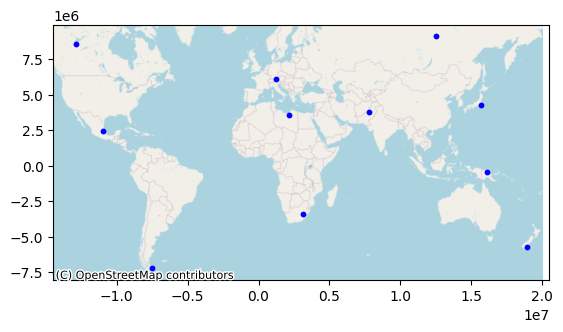

In [3]:
fn = "data/sample_patches.geojson"
gdf = gpd.read_file(fn)
gdf2 = gdf.to_crs("EPSG:3857")
centroids = [row.geometry.centroid.coords[0] for i, row in gdf2.iterrows()]

fig, ax = plt.subplots()
gdf2.plot(ax=ax)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf2.crs)
for x, y in centroids:
    ax.scatter(x, y, color="blue", s=10, zorder=3)
plt.show()

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


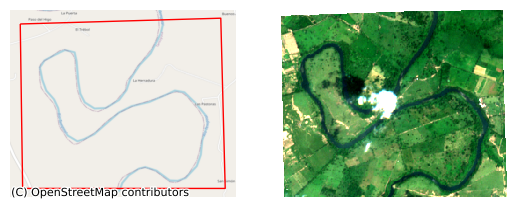

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


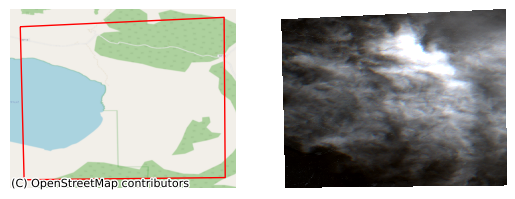

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


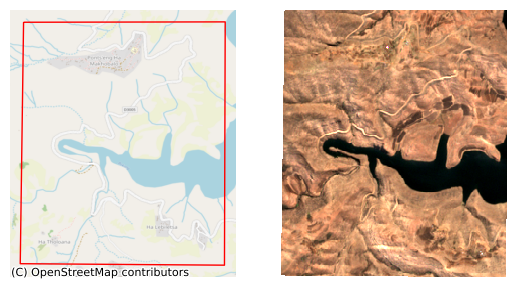

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


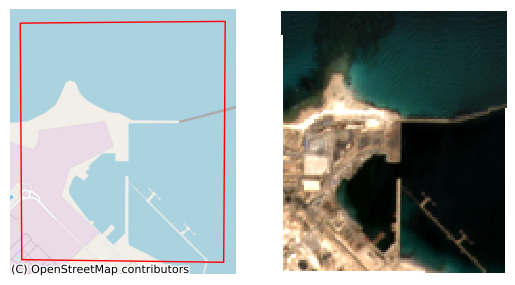

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


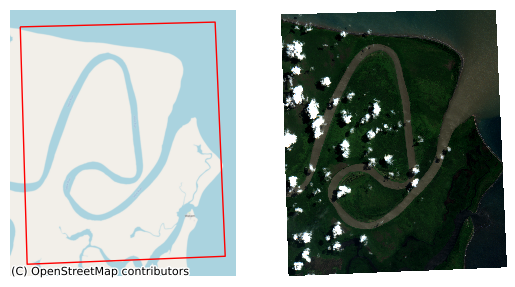

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


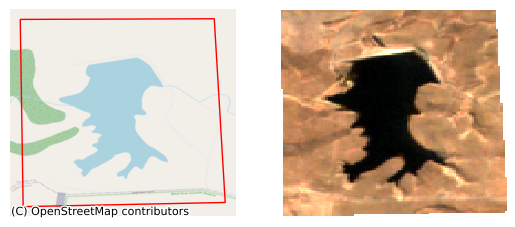

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


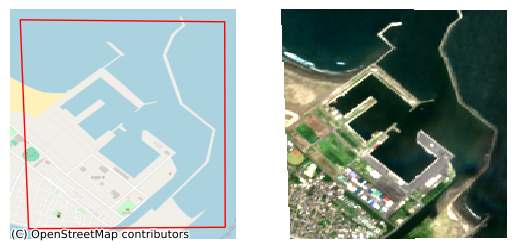

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


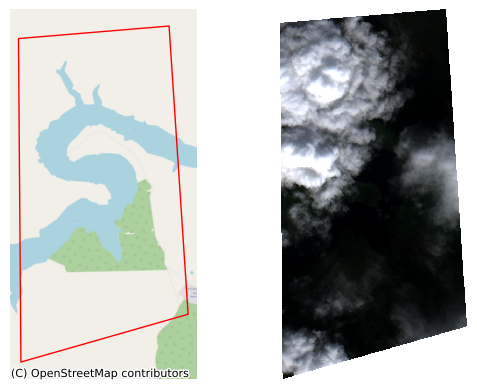

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


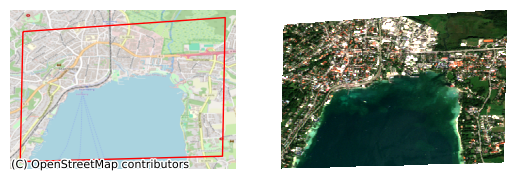

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


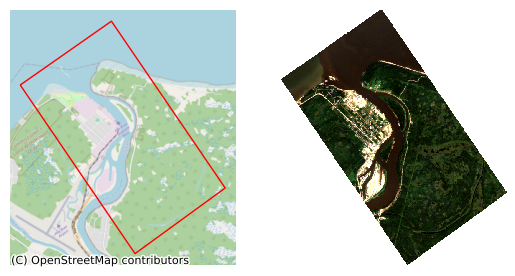

/tmp/ipykernel_1833079/492399871.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]


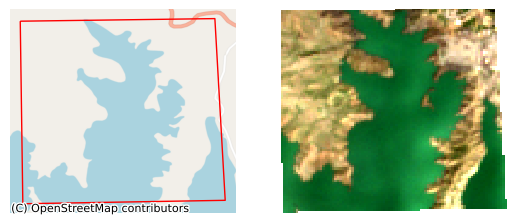

In [4]:
np.random.seed(0)
for i in gdf.index:
    row = gdf.loc[[i]]
    # select a random geographic or projected crs
    row = row.to_crs("EPSG:4326")
    lat, lon = row.geometry.centroid.y.values[0], row.geometry.centroid.x.values[0]
    local_crs_list = pyproj.database.query_crs_info(
        "EPSG", area_of_interest=pyproj.aoi.AreaOfInterest(lon, lat, lon, lat)
    )
    while True:
        idx = np.random.randint(0, len(local_crs_list))
        local_crs = pyproj.CRS.from_epsg(local_crs_list[idx].code)
        if local_crs.is_projected or local_crs.is_geographic:
            break
    row = row.to_crs(local_crs)

    # download the first image
    items = tg.search(
        shp=row,
        collection="sentinel-2-l2a",
        start_date="2022-06-01",
        end_date="2022-08-31",
        bands=["B04", "B03", "B02"],
        resolution=10,
        filter={"eo:cloud_cover": {"lt": 50}},
    )
    items = items[:1]  # take the first element
    da = tg.download(items)

    # plot the image
    fig, ax = plt.subplots(1, 2)
    row.plot(ax=ax[0], facecolor="none", edgecolor="red")
    ctx.add_basemap(ax[0], source=ctx.providers.OpenStreetMap.Mapnik, crs=row.crs)
    da.isel(time=0)[["B04", "B03", "B02"]].to_array().plot.imshow(robust=True, ax=ax[1])
    for x in ax:
        x.set_axis_off()
        x.set_aspect("equal")
        x.set_title("")
    plt.show()